Training samples: 7831
Testing samples : 1958

Training: Linear Regression
Training: Decision Tree
Training: Random Forest

================ MODEL PERFORMANCE ================

            Model        MSE    RMSE  R2 Score
Linear Regression 179873.357 424.115     0.632
    Decision Tree 235419.065 485.200     0.519
    Random Forest 178596.334 422.607     0.635

Best Model based on R²:
Random Forest -> R² = 0.635

Best Model based on MSE:
Random Forest -> MSE = 178596.334


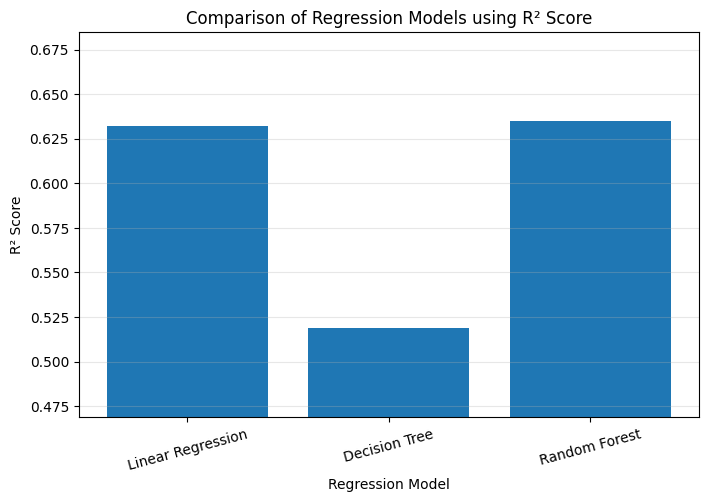

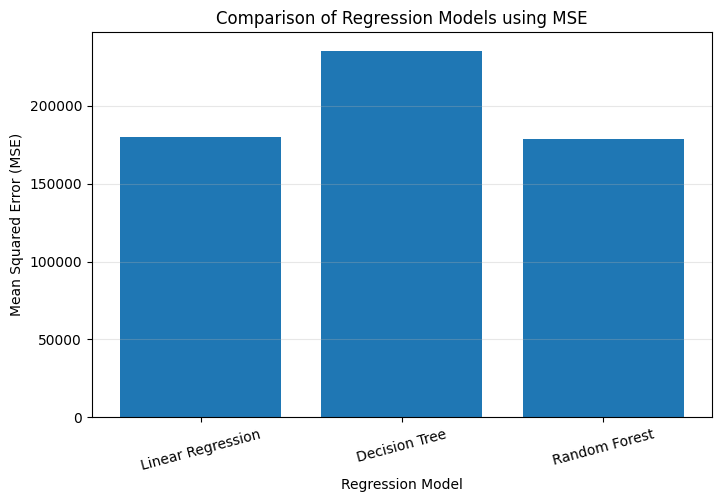

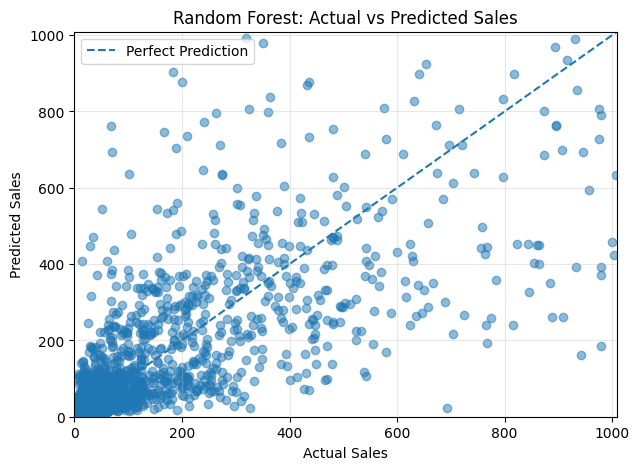

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("/content/exp_3_train.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df = df.dropna()
features = [
    "Ship Mode",
    "Segment",
    "Region",
    "State",
    "City",
    "Category",
    "Sub-Category",
    "Product Name",
    "Year",
    "Month",
    "Ship Days"]
X = df[features]
y = df["Sales"]
categorical = [
    "Ship Mode",
    "Segment",
    "Region",
    "State",
    "City",
    "Category",
    "Sub-Category",
    "Product Name"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)],
    remainder="passthrough")
X = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print()
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=20),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1)}
results = []
predictions = {}
for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2})
    predictions[name] = y_pred
results_df = pd.DataFrame(results)
print("\n================ MODEL PERFORMANCE ================\n")
print(results_df.round(3).to_string(index=False))
best_r2 = results_df.loc[results_df["R2 Score"].idxmax()]
best_mse = results_df.loc[results_df["MSE"].idxmin()]
print("\n====================================================")
print("Best Model based on R²:")
print(best_r2["Model"], "-> R² =", round(best_r2["R2 Score"], 3))
print("\nBest Model based on MSE:")
print(best_mse["Model"], "-> MSE =", round(best_mse["MSE"], 3))
print("====================================================")
plt.figure(figsize=(8, 5))
plt.bar(
    results_df["Model"],
    results_df["R2 Score"])
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models using R² Score")
plt.ylim(
    min(results_df["R2 Score"]) - 0.05,
    min(1.0, max(results_df["R2 Score"]) + 0.05))
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.show()
plt.figure(figsize=(8, 5))
plt.bar(
    results_df["Model"],
    results_df["MSE"])
plt.xlabel("Regression Model")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of Regression Models using MSE")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.show()
best_model_name = best_r2["Model"]
best_predictions = predictions[best_model_name]
limit = y_test.quantile(0.95)
plt.figure(figsize=(7, 5))
plt.scatter(
    y_test[y_test <= limit],
    best_predictions[y_test <= limit],
    alpha=0.5)
plt.plot(
    [0, limit],
    [0, limit],
    linestyle="--",
    label="Perfect Prediction")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"{best_model_name}: Actual vs Predicted Sales")
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.legend()
plt.grid(alpha=0.3)
plt.show()